In [1]:

import os

print(os.listdir("../data/raw"))

[]


In [2]:
df.to_csv("../data/raw/sales.csv", index=False)

print("File saved successfully!")

NameError: name 'df' is not defined

In [ ]:
import os

os.makedirs("../data/raw", exist_ok=True)

print("Folder created successfully!")

In [ ]:
df.to_csv("../data/raw/sales.csv", index=False)

print("File saved successfully!")

In [ ]:
import os
print(os.getcwd())

In [ ]:
import os

os.makedirs("data/raw", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders created!")

In [ ]:
df.to_csv("data/raw/sales.csv", index=False)
print("Saved successfully!")

In [3]:
import pandas as pd
import numpy as np

# create dataset
dates = pd.date_range(start="2022-01-01", periods=730)

np.random.seed(42)
trend = np.linspace(50, 200, len(dates))
seasonality = 20 * np.sin(np.linspace(0, 20, len(dates)))
noise = np.random.normal(0, 10, len(dates))

sales = trend + seasonality + noise

df = pd.DataFrame({
    "Date": dates,
    "Sales": sales.astype(int)
})

df.head()

,Date,Sales
0,2022-01-01,54
1,2022-01-02,49
2,2022-01-03,57
3,2022-01-04,67
4,2022-01-05,50


In [4]:
import os

# create folder if not exists
os.makedirs("data/raw", exist_ok=True)

# save file
df.to_csv("data/raw/sales.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [5]:
import os
print(os.listdir("data/raw"))

['.ipynb_checkpoints', 'sales.csv']


In [6]:
import pandas as pd

df = pd.read_csv("data/raw/sales.csv")
df.head()




,Date,Sales
0,2022-01-01,54
1,2022-01-02,49
2,2022-01-03,57
3,2022-01-04,67
4,2022-01-05,50


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    730 non-null    object
 1   Sales   730 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.5+ KB


In [8]:
# check missing values
print(df.isnull().sum())

# ensure correct datatype
df['Date'] = pd.to_datetime(df['Date'])

# sort data
df = df.sort_values('Date')

# set Date as index (IMPORTANT for time series)
df.set_index('Date', inplace=True)

df.head()

Date     0
Sales    0
dtype: int64


,Sales
Date,
2022-01-01,54
2022-01-02,49
2022-01-03,57
2022-01-04,67
2022-01-05,50


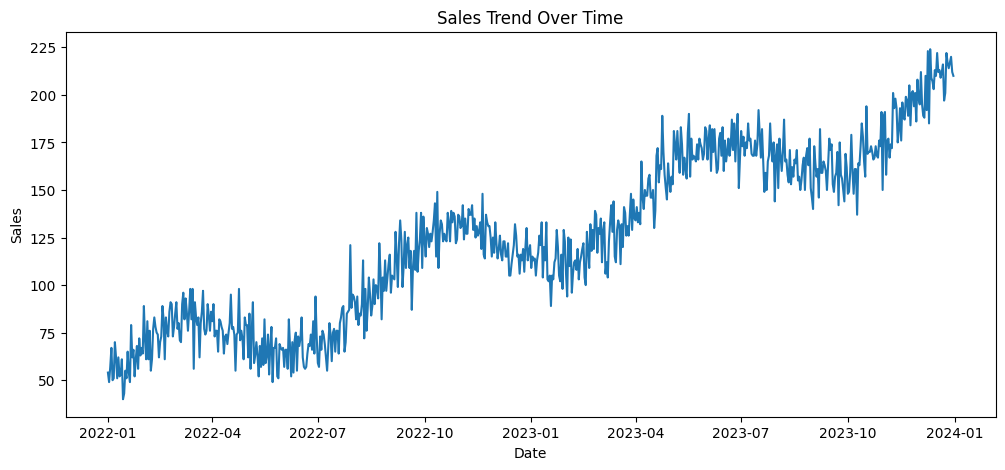

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index, df['Sales'])
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

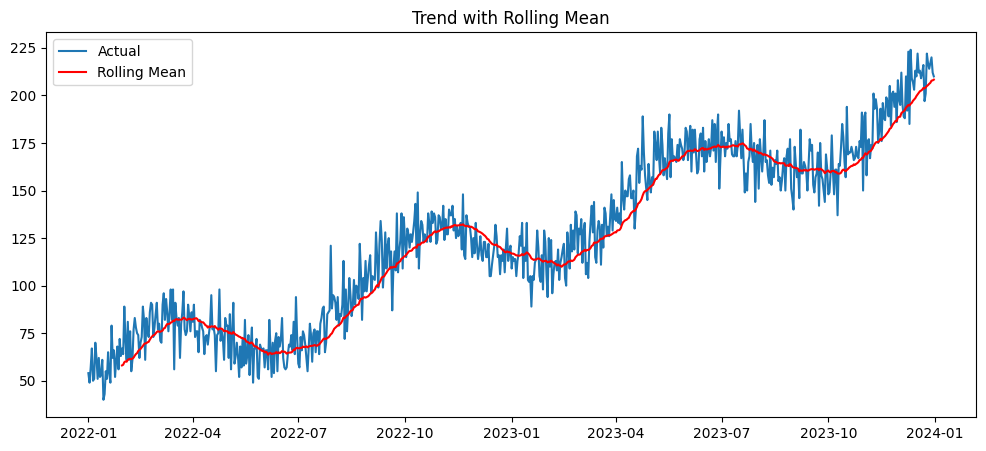

In [10]:
df['Rolling_Mean'] = df['Sales'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Sales'], label='Actual')
plt.plot(df['Rolling_Mean'], label='Rolling Mean', color='red')
plt.legend()
plt.title("Trend with Rolling Mean")
plt.show()

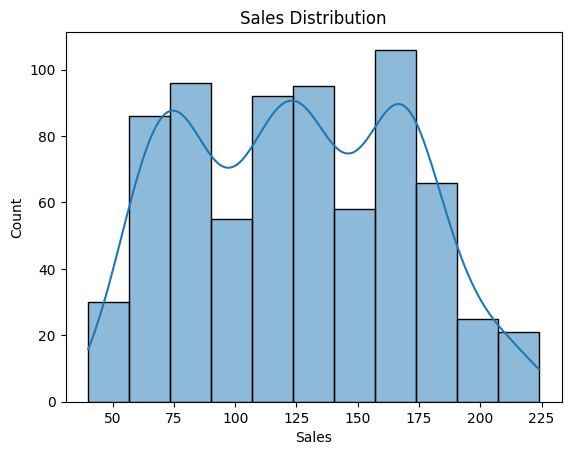

In [11]:
import seaborn as sns

sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

In [12]:
!pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from statsmodels.tsa.arima.model import ARIMA

# fit ARIMA
model = ARIMA(df['Sales'], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\shwet\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\shwet\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\shwet\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  730
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2765.610
Date:                Wed, 15 Apr 2026   AIC                           5543.221
Time:                        00:47:44   BIC                           5570.771
Sample:                    01-01-2022   HQIC                          5553.850
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8305      0.037    -22.542      0.000      -0.903      -0.758
ar.L2         -0.6405      0.047    -13.554      0.000      -0.733      -0.548
ar.L3         -0.4484      0.051     -8.793      0.0

In [14]:
forecast_steps = 30

forecast = model_fit.forecast(steps=forecast_steps)

forecast

2024-01-01    214.853017
2024-01-02    214.113517
2024-01-03    214.906447
2024-01-04    214.586981
2024-01-05    213.255650
2024-01-06    213.676344
2024-01-07    214.158963
2024-01-08    214.070010
2024-01-09    214.179029
2024-01-10    213.997012
2024-01-11    213.874748
2024-01-12    213.996438
2024-01-13    214.030655
2024-01-14    214.026775
2024-01-15    214.027650
2024-01-16    213.990350
2024-01-17    213.990086
2024-01-18    214.009557
2024-01-19    214.010605
2024-01-20    214.010690
2024-01-21    214.007468
2024-01-22    214.002640
2024-01-23    214.005085
2024-01-24    214.007388
2024-01-25    214.007222
2024-01-26    214.007061
2024-01-27    214.006183
2024-01-28    214.005856
2024-01-29    214.006442
2024-01-30    214.006644
Freq: D, Name: predicted_mean, dtype: float64

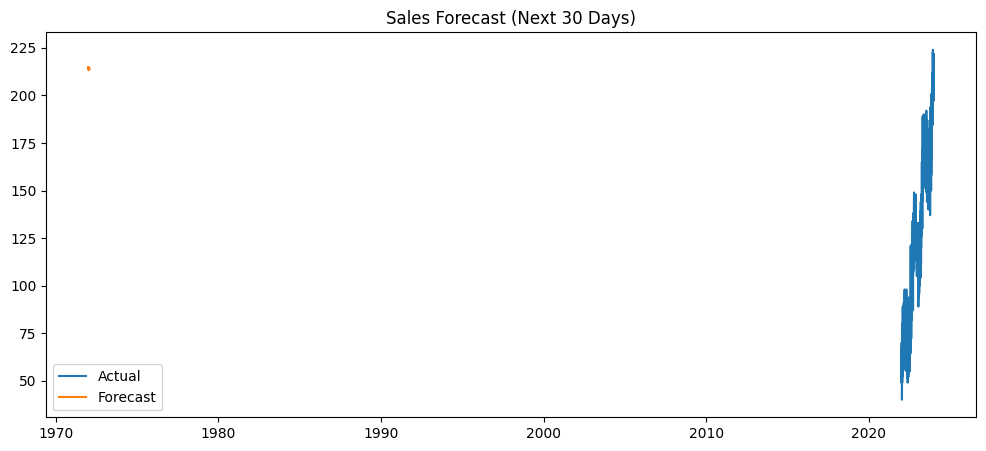

In [15]:
plt.figure(figsize=(12,5))

# actual
plt.plot(df['Sales'], label='Actual')

# forecast
plt.plot(range(len(df), len(df)+forecast_steps), forecast, label='Forecast')

plt.legend()
plt.title("Sales Forecast (Next 30 Days)")
plt.show()

In [16]:
import numpy as np

avg_demand = df['Sales'].mean()
std_demand = df['Sales'].std()

lead_time = 7

# safety stock
safety_stock = 1.65 * std_demand * np.sqrt(lead_time)

# reorder point
reorder_point = (avg_demand * lead_time) + safety_stock

print("Average Demand:", round(avg_demand,2))
print("Std Dev Demand:", round(std_demand,2))
print("Safety Stock:", round(safety_stock,2))
print("Reorder Point:", round(reorder_point,2))

Average Demand: 124.94
Std Dev Demand: 44.19
Safety Stock: 192.92
Reorder Point: 1067.5


In [17]:
inventory_df = pd.DataFrame({
    "Metric": ["Average Demand", "Std Dev Demand", "Safety Stock", "Reorder Point"],
    "Value": [avg_demand, std_demand, safety_stock, reorder_point]
})

inventory_df

,Metric,Value
0,Average Demand,124.939726
1,Std Dev Demand,44.191616
2,Safety Stock,192.918045
3,Reorder Point,1067.496127


In [18]:
current_stock = 800  # assume

if current_stock < reorder_point:
    print("⚠️ ALERT: Reorder Required!")
else:
    print("✅ Stock is sufficient.")

⚠️ ALERT: Reorder Required!


In [19]:
# save forecast
forecast_df = pd.DataFrame(forecast)
forecast_df.to_csv("outputs/forecast.csv")

# save inventory
inventory_df.to_csv("outputs/inventory.csv", index=False)

print("All outputs saved!")

All outputs saved!


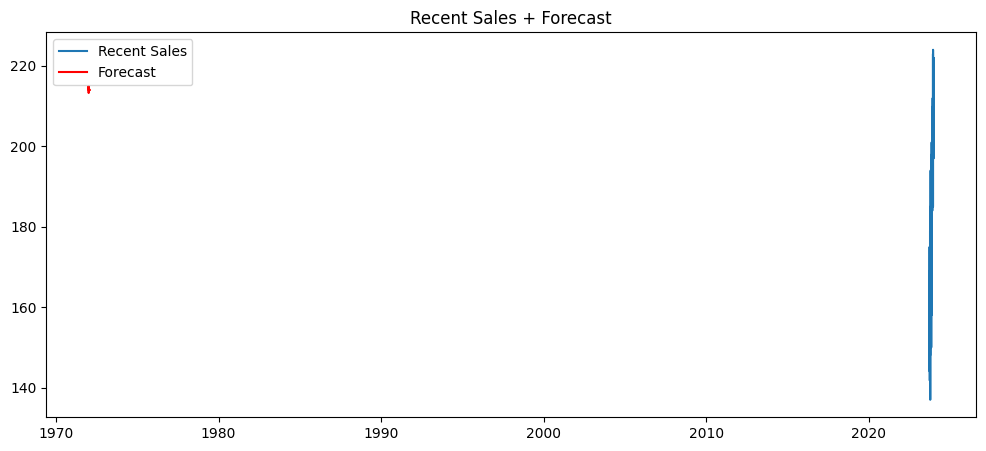

In [20]:
plt.figure(figsize=(12,5))
plt.plot(df['Sales'][-100:], label="Recent Sales")
plt.plot(range(len(df), len(df)+30), forecast, label="Forecast", color='red')
plt.legend()
plt.title("Recent Sales + Forecast")
plt.show()

In [21]:
import pandas as pd
import numpy as np

np.random.seed(42)

dates = pd.date_range(start="2023-01-01", periods=365)

stores = ["Store_A", "Store_B"]
skus = ["Milk", "Bread", "Eggs"]

data = []

for store in stores:
    for sku in skus:
        base = np.random.randint(40, 100)
        trend = np.linspace(base, base+50, len(dates))
        seasonality = 10 * np.sin(np.linspace(0, 10, len(dates)))
        noise = np.random.normal(0, 5, len(dates))

        demand = trend + seasonality + noise

        # simulate stock
        stock = np.random.randint(50, 150, len(dates))

        sales = np.minimum(demand, stock)  # stock constraint

        for i in range(len(dates)):
            data.append([
                dates[i], store, sku,
                int(demand[i]), int(stock[i]), int(sales[i])
            ])

df_multi = pd.DataFrame(data, columns=[
    "Date", "Store", "SKU", "Demand", "Stock", "Sales"
])

df_multi.head()

,Date,Store,SKU,Demand,Stock,Sales
0,2023-01-01,Store_A,Milk,75,69,69
1,2023-01-02,Store_A,Milk,80,141,80
2,2023-01-03,Store_A,Milk,81,121,81
3,2023-01-04,Store_A,Milk,86,110,86
4,2023-01-05,Store_A,Milk,75,88,75


In [22]:
df_multi['Stockout'] = df_multi['Sales'] < df_multi['Demand']

df_multi[['Sales', 'Demand', 'Stockout']].head(10)

,Sales,Demand,Stockout
0,69,75,True
1,80,80,False
2,81,81,False
3,86,86,False
4,75,75,False
5,50,79,True
6,52,70,True
7,78,78,False
8,83,83,False
9,77,77,False


In [23]:
df_multi['Adjusted_Demand'] = df_multi['Sales']

# replace where stockout
df_multi.loc[df_multi['Stockout'], 'Adjusted_Demand'] = df_multi['Demand']

df_multi.head()

,Date,Store,SKU,Demand,Stock,Sales,Stockout,Adjusted_Demand
0,2023-01-01,Store_A,Milk,75,69,69,True,75
1,2023-01-02,Store_A,Milk,80,141,80,False,80
2,2023-01-03,Store_A,Milk,81,121,81,False,81
3,2023-01-04,Store_A,Milk,86,110,86,False,86
4,2023-01-05,Store_A,Milk,75,88,75,False,75


In [25]:
df_multi['Date'] = pd.to_datetime(df_multi['Date'])

df_multi['day'] = df_multi['Date'].dt.day
df_multi['month'] = df_multi['Date'].dt.month
df_multi['weekday'] = df_multi['Date'].dt.weekday

In [26]:
df_subset = df_multi[
    (df_multi['Store'] == "Store_A") &
    (df_multi['SKU'] == "Milk")
]

df_subset.set_index('Date', inplace=True)

In [27]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df_subset['Adjusted_Demand'], order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

forecast.head()

C:\Users\shwet\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\shwet\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\shwet\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2024-01-01    119.173764
2024-01-02    118.929273
2024-01-03    120.128508
2024-01-04    121.808977
2024-01-05    121.176985
Freq: D, Name: predicted_mean, dtype: float64

In [28]:
results = []

for store in df_multi['Store'].unique():
    for sku in df_multi['SKU'].unique():

        temp = df_multi[
            (df_multi['Store'] == store) &
            (df_multi['SKU'] == sku)
        ].copy()

        temp.set_index('Date', inplace=True)

        model = ARIMA(temp['Adjusted_Demand'], order=(2,1,0))
        model_fit = model.fit()

        forecast = model_fit.forecast(steps=7)

        for i, val in enumerate(forecast):
            results.append([store, sku, i+1, val])

forecast_df = pd.DataFrame(results, columns=[
    "Store", "SKU", "Day", "Forecast"
])

forecast_df.head()

C:\Users\shwet\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\shwet\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\shwet\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\shwet\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\shwet\AppData\Local\Programs\Python\Python310\lib\s

,Store,SKU,Day,Forecast
0,Store_A,Milk,1,121.175588
1,Store_A,Milk,2,123.233232
2,Store_A,Milk,3,124.513618
3,Store_A,Milk,4,122.998620
4,Store_A,Milk,5,123.551303


In [29]:
inventory_results = []

for store in df_multi['Store'].unique():
    for sku in df_multi['SKU'].unique():

        temp = df_multi[
            (df_multi['Store'] == store) &
            (df_multi['SKU'] == sku)
        ]

        avg = temp['Adjusted_Demand'].mean()
        std = temp['Adjusted_Demand'].std()

        lead_time = 7

        safety = 1.65 * std * np.sqrt(lead_time)
        reorder = (avg * lead_time) + safety

        inventory_results.append([store, sku, avg, safety, reorder])

inventory_df = pd.DataFrame(inventory_results, columns=[
    "Store", "SKU", "Avg Demand", "Safety Stock", "Reorder Point"
])

inventory_df

,Store,SKU,Avg Demand,Safety Stock,Reorder Point
0,Store_A,Milk,104.205479,71.569217,801.007573
1,Store_A,Bread,114.657534,71.315876,873.918616
2,Store_A,Eggs,79.421918,70.853644,626.807069
3,Store_B,Milk,75.545205,72.611719,601.428158
4,Store_B,Bread,69.463014,71.604016,557.845112
5,Store_B,Eggs,108.309589,69.584245,827.751368


ValueError: x and y must have same first dimension, but have shapes (30,) and (7,)

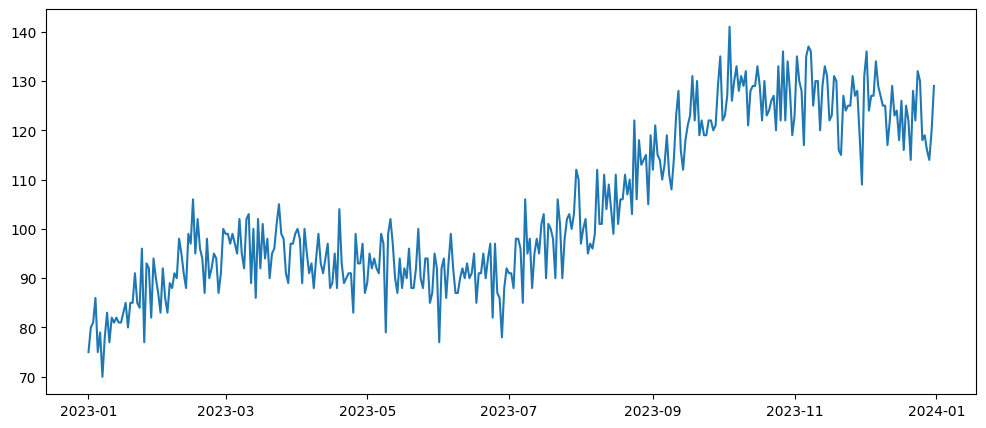

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df_subset['Adjusted_Demand'], label="Actual")
plt.plot(range(len(df_subset), len(df_subset)+30), forecast, label="Forecast")

plt.legend()
plt.title("SKU-Store Forecast")
plt.show()

In [31]:
df = pd.read_csv("data/raw/sales.csv")
df.head()

,Date,Sales
0,2022-01-01,54
1,2022-01-02,49
2,2022-01-03,57
3,2022-01-04,67
4,2022-01-05,50


In [32]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

Shape: (730, 2)

Columns: Index(['Date', 'Sales'], dtype='object')


In [33]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [34]:
missing = df.isnull().sum()
print(missing)

Date     0
Sales    0
dtype: int64


In [35]:
negative_sales = (df['Sales'] < 0).sum()
print("Negative values:", negative_sales)

Negative values: 0


In [36]:
import numpy as np

np.random.seed(42)

df['Stock'] = np.random.randint(50, 150, size=len(df))

In [38]:
df['Stockout'] = df['Sales'] >= df['Stock']

df.head()

,Date,Sales,Stock,Stockout
0,2022-01-01,54,101,False
1,2022-01-02,49,142,False
2,2022-01-03,57,64,False
3,2022-01-04,67,121,False
4,2022-01-05,50,110,False


In [39]:
df['Adjusted_Sales'] = df['Sales']

df.loc[df['Stockout'], 'Adjusted_Sales'] = df['Stock']

In [40]:
df[['Sales', 'Stock', 'Adjusted_Sales']].head(10)

,Sales,Stock,Adjusted_Sales
0,54,101,54
1,49,142,49
2,57,64,57
3,67,121,67
4,50,110,50
5,51,70,51
6,70,132,70
7,62,136,62
8,51,124,51
9,62,124,62


In [41]:
df_clean = df.copy()

df_clean = df_clean[['Date', 'Adjusted_Sales']]
df_clean.rename(columns={'Adjusted_Sales': 'Sales'}, inplace=True)

df_clean.head()

,Date,Sales
0,2022-01-01,54
1,2022-01-02,49
2,2022-01-03,57
3,2022-01-04,67
4,2022-01-05,50


In [42]:
df_clean.to_csv("data/processed/clean_sales.csv", index=False)

print("Clean data saved!")

Clean data saved!


In [43]:
report = {
    "Total Rows": len(df),
    "Duplicates": duplicate_count,
    "Missing Values": df.isnull().sum().sum(),
    "Negative Values": negative_sales,
    "Stockout Rows": df['Stockout'].sum()
}

for k, v in report.items():
    print(f"{k}: {v}")

Total Rows: 730
Duplicates: 0
Missing Values: 0
Negative Values: 0
Stockout Rows: 489


In [44]:
df_multi.head()

,Date,Store,SKU,Demand,Stock,Sales,Stockout,Adjusted_Demand,day,month,weekday
0,2023-01-01,Store_A,Milk,75,69,69,True,75,1,1,6
1,2023-01-02,Store_A,Milk,80,141,80,False,80,2,1,0
2,2023-01-03,Store_A,Milk,81,121,81,False,81,3,1,1
3,2023-01-04,Store_A,Milk,86,110,86,False,86,4,1,2
4,2023-01-05,Store_A,Milk,75,88,75,False,75,5,1,3


In [45]:
df_multi['Zero_Demand'] = df_multi['Sales'] == 0

In [46]:
zero_share = df_multi.groupby('SKU')['Zero_Demand'].mean().reset_index()

zero_share.rename(columns={'Zero_Demand': 'Zero_Demand_Share'}, inplace=True)

zero_share

,SKU,Zero_Demand_Share
0,Bread,0.0
1,Eggs,0.0
2,Milk,0.0


In [49]:
def classify_demand(x):
    if x > 0.5:
        return "Highly Intermittent"
    elif x > 0.2:
        return "Moderate Intermittent"
    else:
        return "Regular"

zero_share['Demand_Type'] = zero_share['Zero_Demand_Share'].apply(classify_demand)

zero_share

,SKU,Zero_Demand_Share,Demand_Type
0,Bread,0.0,Regular
1,Eggs,0.0,Regular
2,Milk,0.0,Regular


In [50]:
croston_candidates = zero_share[zero_share['Zero_Demand_Share'] > 0.4]

croston_candidates

,SKU,Zero_Demand_Share,Demand_Type


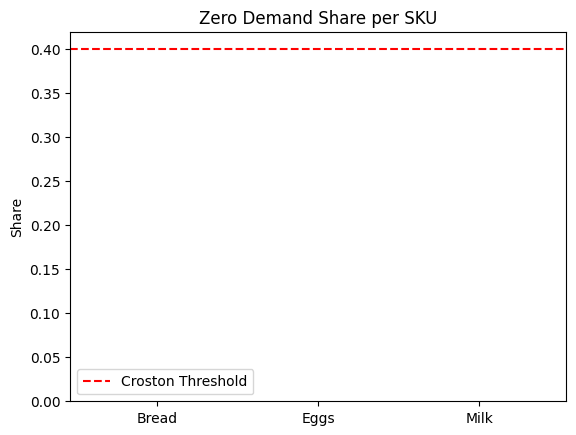

In [51]:
import matplotlib.pyplot as plt

plt.bar(zero_share['SKU'], zero_share['Zero_Demand_Share'])
plt.axhline(y=0.4, color='red', linestyle='--', label='Croston Threshold')
plt.title("Zero Demand Share per SKU")
plt.ylabel("Share")
plt.legend()
plt.show()

In [52]:
final_table = zero_share.copy()

final_table['Recommended_Model'] = final_table['Zero_Demand_Share'].apply(
    lambda x: "Croston" if x > 0.4 else "ARIMA"
)

final_table

,SKU,Zero_Demand_Share,Demand_Type,Recommended_Model
0,Bread,0.0,Regular,ARIMA
1,Eggs,0.0,Regular,ARIMA
2,Milk,0.0,Regular,ARIMA


In [53]:
df_multi.head()

,Date,Store,SKU,Demand,Stock,Sales,Stockout,Adjusted_Demand,day,month,weekday,Zero_Demand
0,2023-01-01,Store_A,Milk,75,69,69,True,75,1,1,6,False
1,2023-01-02,Store_A,Milk,80,141,80,False,80,2,1,0,False
2,2023-01-03,Store_A,Milk,81,121,81,False,81,3,1,1,False
3,2023-01-04,Store_A,Milk,86,110,86,False,86,4,1,2,False
4,2023-01-05,Store_A,Milk,75,88,75,False,75,5,1,3,False


In [57]:
df_multi['Date'] = pd.to_datetime(df_multi['Date'])

df_multi = df_multi.sort_values(['Store', 'SKU', 'Date'])

In [59]:
df_multi['lag_1'] = df_multi.groupby(['Store', 'SKU'])['Sales'].shift(1)
df_multi['lag_7'] = df_multi.groupby(['Store', 'SKU'])['Sales'].shift(7)
df_multi['lag_14'] = df_multi.groupby(['Store', 'SKU'])['Sales'].shift(14)

In [60]:
sample_df = df_multi.head(1000)

sample_df['lag_1'] = sample_df.groupby(['Store', 'SKU'])['Sales'].shift(1)

sample_df.head()

C:\Users\shwet\AppData\Local\Temp\ipykernel_25384\1265846431.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['lag_1'] = sample_df.groupby(['Store', 'SKU'])['Sales'].shift(1)


,Date,Store,SKU,Demand,Stock,Sales,Stockout,Adjusted_Demand,day,month,weekday,Zero_Demand,lag_1,lag_7,lag_14
365,2023-01-01,Store_A,Bread,78,141,78,False,78,1,1,6,False,NaN,NaN,NaN
366,2023-01-02,Store_A,Bread,97,146,97,False,97,2,1,0,False,78.0,NaN,NaN
367,2023-01-03,Store_A,Bread,90,108,90,False,90,3,1,1,False,97.0,NaN,NaN
368,2023-01-04,Store_A,Bread,88,108,88,False,88,4,1,2,False,90.0,NaN,NaN
369,2023-01-05,Store_A,Bread,90,97,90,False,90,5,1,3,False,88.0,NaN,NaN


In [61]:
print(df_multi.shape)

(2190, 15)


In [68]:
df_multi = df_multi.sort_values(['Store', 'SKU', 'Date'])

# create lag features efficiently
for lag in [1, 7, 14]:
    df_multi[f'lag_{lag}'] = df_multi.groupby(['Store', 'SKU'])['Sales'].transform(lambda x: x.shift(lag))

In [69]:
# STEP 1: SORT DATA (IMPORTANT)
df_multi = df_multi.sort_values(['Store', 'SKU', 'Date'])

# STEP 2: CREATE LAGS (FASTEST METHOD)
group = df_multi.groupby(['Store', 'SKU'])['Sales']

df_multi['lag_1'] = group.shift(1)
df_multi['lag_7'] = group.shift(7)
df_multi['lag_14'] = group.shift(14)

print("Lag features created successfully!")

Lag features created successfully!


In [70]:
import time

start = time.time()

group = df_multi.groupby(['Store', 'SKU'])['Sales']
df_multi['lag_1'] = group.shift(1)

end = time.time()

print("Time taken:", end - start)

Time taken: 0.007176876068115234


In [71]:
import time

start = time.time()

group = df_multi.groupby(['Store', 'SKU'])['Sales']
df_multi['lag_1'] = group.shift(1)

end = time.time()

print("Time taken:", end - start)

Time taken: 0.004999637603759766


In [72]:
# rolling features (FAST + CORRECT)
df_multi['rolling_mean_7'] = (
    df_multi.groupby(['Store','SKU'])['Sales']
    .shift(1)
    .rolling(7)
    .mean()
)

df_multi['rolling_mean_14'] = (
    df_multi.groupby(['Store','SKU'])['Sales']
    .shift(1)
    .rolling(14)
    .mean()
)

df_multi['rolling_std_7'] = (
    df_multi.groupby(['Store','SKU'])['Sales']
    .shift(1)
    .rolling(7)
    .std()
)

print("Rolling features created!")
df_multi.head()

Rolling features created!


,Date,Store,SKU,Demand,Stock,Sales,Stockout,Adjusted_Demand,day,month,weekday,Zero_Demand,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_std_7
365,2023-01-01,Store_A,Bread,78,141,78,False,78,1,1,6,False,NaN,NaN,NaN,NaN,NaN,NaN
366,2023-01-02,Store_A,Bread,97,146,97,False,97,2,1,0,False,78.0,NaN,NaN,NaN,NaN,NaN
367,2023-01-03,Store_A,Bread,90,108,90,False,90,3,1,1,False,97.0,NaN,NaN,NaN,NaN,NaN
368,2023-01-04,Store_A,Bread,88,108,88,False,88,4,1,2,False,90.0,NaN,NaN,NaN,NaN,NaN
369,2023-01-05,Store_A,Bread,90,97,90,False,90,5,1,3,False,88.0,NaN,NaN,NaN,NaN,NaN


In [73]:
df_multi['day'] = df_multi['Date'].dt.day
df_multi['month'] = df_multi['Date'].dt.month
df_multi['weekday'] = df_multi['Date'].dt.weekday

df_multi['is_weekend'] = df_multi['weekday'].isin([5,6]).astype(int)

print("Calendar features created!")
df_multi.head()

Calendar features created!


,Date,Store,SKU,Demand,Stock,Sales,Stockout,Adjusted_Demand,day,month,weekday,Zero_Demand,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_std_7,is_weekend
365,2023-01-01,Store_A,Bread,78,141,78,False,78,1,1,6,False,NaN,NaN,NaN,NaN,NaN,NaN,1
366,2023-01-02,Store_A,Bread,97,146,97,False,97,2,1,0,False,78.0,NaN,NaN,NaN,NaN,NaN,0
367,2023-01-03,Store_A,Bread,90,108,90,False,90,3,1,1,False,97.0,NaN,NaN,NaN,NaN,NaN,0
368,2023-01-04,Store_A,Bread,88,108,88,False,88,4,1,2,False,90.0,NaN,NaN,NaN,NaN,NaN,0
369,2023-01-05,Store_A,Bread,90,97,90,False,90,5,1,3,False,88.0,NaN,NaN,NaN,NaN,NaN,0


In [74]:
df_multi.isnull().sum()

Date                0
Store               0
SKU                 0
Demand              0
Stock               0
Sales               0
Stockout            0
Adjusted_Demand     0
day                 0
month               0
weekday             0
Zero_Demand         0
lag_1               6
lag_7              42
lag_14             84
rolling_mean_7     42
rolling_mean_14    84
rolling_std_7      42
is_weekend          0
dtype: int64

In [75]:
df_features = df_multi.dropna()

print("After dropping NA:", df_features.shape)

After dropping NA: (2106, 19)


In [76]:
features = [
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7',
    'day', 'month', 'weekday', 'is_weekend'
]

X = df_features[features]
y = df_features['Sales']

In [77]:
split = int(len(df_features) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1684
Test size: 422


In [78]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [79]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ 88.54,  75.01,  78.15,  85.35,  88.29, 101.89,  98.2 ,  82.98,
        82.  ,  93.7 ])

In [80]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", round(mae,2))

MAE: 10.37


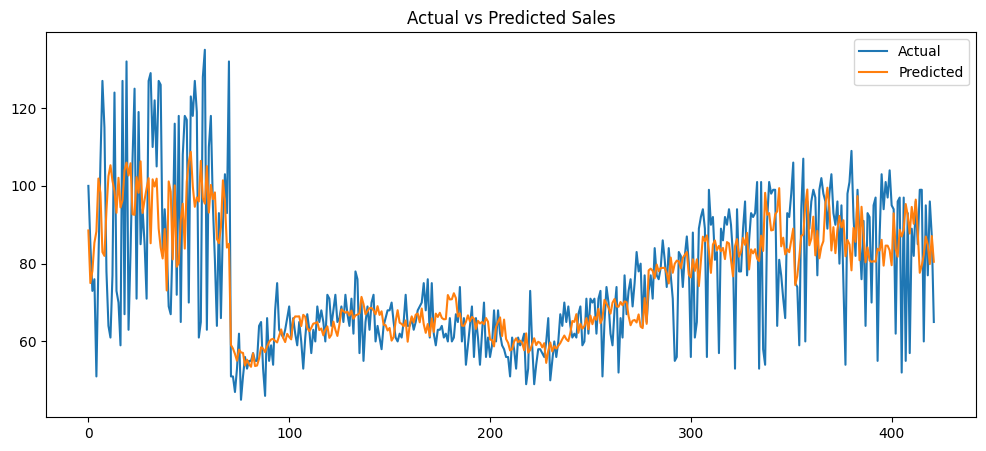

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [82]:
import numpy as np

avg_demand = y.mean()
std_demand = y.std()

lead_time = 7

safety_stock = 1.65 * std_demand * np.sqrt(lead_time)
reorder_point = (avg_demand * lead_time) + safety_stock

print("Safety Stock:", round(safety_stock,2))
print("Reorder Point:", round(reorder_point,2))

Safety Stock: 90.61
Reorder Point: 655.58


In [83]:
# predictions
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

pred_df.to_csv("outputs/predictions.csv", index=False)

# feature dataset
df_features.to_csv("data/processed/feature_data.csv", index=False)

print("All outputs saved!")

All outputs saved!


In [84]:
# classify SKUs
zero_share = df_multi.groupby('SKU')['Sales'].apply(lambda x: (x==0).mean())

def select_model(x):
    if x > 0.4:
        return "Croston"
    else:
        return "ML"

model_map = zero_share.apply(select_model)
print(model_map)

SKU
Bread    ML
Eggs     ML
Milk     ML
Name: Sales, dtype: object


In [85]:
import numpy as np

def croston_sba(ts, alpha=0.1):
    ts = np.array(ts)
    
    demand = ts[ts > 0]
    intervals = np.diff(np.where(ts > 0)[0])
    
    if len(demand) == 0:
        return 0
    
    q = demand[0]
    p = intervals[0] if len(intervals) > 0 else 1
    
    for i in range(1, len(demand)):
        q = q + alpha * (demand[i] - q)
        if i < len(intervals):
            p = p + alpha * (intervals[i] - p)
    
    croston = q / p
    sba = croston * (1 - alpha/2)  # SBA correction
    
    return sba

In [86]:
croston_sba(df_subset['Sales'])

np.float64(89.99426915613579)

In [87]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def mase(y_true, y_pred):
    naive = np.mean(np.abs(np.diff(y_true)))
    return np.mean(np.abs(y_true - y_pred)) / naive

def backtest(series, model_func, window=100, horizon=7):
    errors = []

    for i in range(window, len(series)-horizon):
        train = series[:i]
        test = series[i:i+horizon]
        
        if model_func == "croston":
            pred = [croston_sba(train)] * horizon
        else:
            pred = [train.iloc[-1]] * horizon  # fallback naive
        
        mae = mean_absolute_error(test, pred)
        rmse = np.sqrt(mean_squared_error(test, pred))
        m = mase(test.values, np.array(pred))
        
        errors.append([mae, rmse, m])
    
    return np.mean(errors, axis=0)

In [88]:
mae, rmse, m = backtest(df_subset['Sales'], "croston")

print("MAE:", mae)
print("RMSE:", rmse)
print("MASE:", m)

MAE: 19.186256461776228
RMSE: 21.397633458446286
MASE: 0.980743060696258


In [89]:
summary = []

for sku in df_multi['SKU'].unique():
    temp = df_multi[df_multi['SKU']==sku]['Sales']
    mae, rmse, m = backtest(temp, "croston")
    
    summary.append([sku, mae, rmse, m])

summary_df = pd.DataFrame(summary, columns=['SKU','MAE','RMSE','MASE'])
summary_df

,SKU,MAE,RMSE,MASE
0,Bread,14.203862,16.018898,1.003631
1,Eggs,14.725255,16.456411,0.966653
2,Milk,13.638967,15.272435,1.102312


In [90]:
import math

def inventory_calc(demand, lead_time=7, service_level=1.65, ordering_cost=50, holding_cost=2):
    avg = np.mean(demand)
    std = np.std(demand)
    
    safety_stock = service_level * std * np.sqrt(lead_time)
    rop = avg * lead_time + safety_stock
    
    annual_demand = avg * 365
    eoq = math.sqrt((2 * annual_demand * ordering_cost) / holding_cost)
    
    return safety_stock, rop, eoq

In [91]:
for sku in ['Milk','Bread','Eggs']:
    data = df_multi[df_multi['SKU']==sku]['Sales']
    
    ss, rop, eoq = inventory_calc(data)
    
    print(sku, ss, rop, eoq)

Milk 85.57585038264966 640.3306449031977 1202.6325290794357
Bread 100.81879282881799 655.1708476233385 1202.1959074959454
Eggs 85.2492316798409 658.6643001729916 1222.6917027607572
